# Q1 Static Compact-Interpolated Validation

This notebook compares the fixed-basis compact-interpolated Lindblad-safe model against direct compact static references.

For each static electric field it evaluates three cases:

- `fixed_interpolated`: the fixed-reference-basis interpolated model evaluated at that field.
- `direct_compact_aligned`: the exact compact patch at that field, embedded/aligned into the fixed model layout.
- `direct_compact_local_rust`: the exact compact OBE built directly at that field and solved in its own local compact basis using the Rust OBE path where possible.

The aligned comparison tests interpolation error directly. The local compact comparison uses basis-invariant observables such as integrated excited-state population and emitted photons.

In [1]:
from __future__ import annotations

import importlib.util
import pathlib
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

from centrex_tlf.lindblad import prepare_lindblad_problem, solve_lindblad


def load_runtime_module():
    cwd = pathlib.Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        runtime_path = (
            candidate / "examples" / "effective hamiltonian" / "effective_hamiltonian_runtime.py"
        )
        if runtime_path.exists():
            spec = importlib.util.spec_from_file_location(
                "effective_hamiltonian_runtime", runtime_path
            )
            module = importlib.util.module_from_spec(spec)
            sys.modules[spec.name] = module
            spec.loader.exec_module(module)
            return module
    raise FileNotFoundError(
        "Could not locate examples/effective hamiltonian/effective_hamiltonian_runtime.py"
    )


plt.rcParams.update({"font.size": 14})
ehr = load_runtime_module()

print("runtime:", pathlib.Path(ehr.__file__).resolve())

runtime: C:\Users\ogras\Documents\GitHub\CeNTREX-TlF\examples\effective hamiltonian\effective_hamiltonian_runtime.py


## Configuration

`RUST_COMPACT_REFERENCE_SOLVER` can be changed to `"tsit5_fast"` for the fastest explicit Rust reference, or to `"scipy_bdf"` for the stiff SciPy-BDF-with-Rust-RHS/Jacobian route. The fixed-basis interpolated model currently uses the `OperatorBundle` path. Its Lindblad-safe interpolated dissipator is reconstructed from the full collapse-operator kernel over `(target, source)` matrix entries, so compact-basis coherences are retained. Per-target excited-state decay kernels are still kept as diagnostics.

The local compact reference is solved in the same common laser frame as the fixed-basis model by shifting its detuning by `omega_patch(E) - omega_reference`. Without this correction, `detuning=0` would retune the laser to each local compact patch.


All dynamics comparisons use the same nominal preparation: uniform population over the active transition ground manifold `X, J=transition.J_ground` in each method's state layout. This avoids comparing a fixed-reference bright state to a local-field bright state.

In [2]:
TRANSITION = ehr.transitions.Q1_F1_1o2_F0
OPTICAL_POLARIZATION = ehr.couplings.polarization_Z

PATCH_POINTS_VCM = [0.0, 5.0, 7.0, 7.5, 8.0, 10.0, 20.0, 30.0, 40.0, 50.0]
MASTER_FIELD_VCM = 10.0

# Start small; expand after confirming the comparison behaves as expected.
STATIC_FIELDS_VCM = [0.0, 7.5, 10.0, 20.0, 50.0]

B_FIELD = (0.0, 0.0, 1e-5)
RABI_RATE = 2.0 * np.pi * 1e6
DETUNING = 0.0
POLARIZATION_SCALE = 1.0

T_FINAL = 2e-6
T_EVAL = np.linspace(0.0, T_FINAL, 251)

BUNDLE_SOLVER_METHOD = "BDF"
RUST_COMPACT_REFERENCE_SOLVER = "scipy_bdf"
RUST_EXECUTION_MODE = "expanded_sparse"
ABSTOL = 1e-9
RELTOL = 1e-7
DT = 1e-10
MAXITERS = 100_000
EXCITED_REL_FLOOR = 1e-12

print(
    {
        "transition": str(TRANSITION),
        "static_fields_vcm": STATIC_FIELDS_VCM,
        "bundle_solver": BUNDLE_SOLVER_METHOD,
        "rust_compact_reference_solver": RUST_COMPACT_REFERENCE_SOLVER,
    }
)

{'transition': "OpticalTransition(Q(1) F1'=1/2 F'=0)", 'static_fields_vcm': [0.0, 7.5, 10.0, 20.0, 50.0], 'bundle_solver': 'BDF', 'rust_compact_reference_solver': 'scipy_bdf'}


## Build Fixed-Basis Interpolated Model

This is the model under test. The direct aligned compact reference below uses the same fixed layout, so matrix and state comparisons are meaningful there.

In [3]:
setup_start = time.perf_counter()
model = ehr.prepare_lindblad_safe_compact_interpolated_model(
    field_points=PATCH_POINTS_VCM,
    transition=TRANSITION,
    optical_polarization=OPTICAL_POLARIZATION,
    magnetic_field=B_FIELD,
    master_field=MASTER_FIELD_VCM,
)
setup_seconds = time.perf_counter() - setup_start

ACTIVE_INDICES = np.concatenate([model.ground_indices, model.excited_indices]).astype(np.int64)
RHO0_FIXED = np.zeros((model.n_effective_states, model.n_effective_states), dtype=np.complex128)
for idx in model.ground_indices:
    RHO0_FIXED[int(idx), int(idx)] = 1.0 / int(model.ground_indices.size)

print(
    {
        "n_effective_states": model.n_effective_states,
        "ground_indices": model.ground_indices.tolist(),
        "sink_indices": model.sink_indices.tolist(),
        "excited_indices": model.excited_indices.tolist(),
        "initial_condition": f"uniform over X,J={TRANSITION.J_ground} active ground manifold",
        "ground_main_index": model.ground_main_index_p,
        "setup_seconds": setup_seconds,
    }
)

{'n_effective_states': 15, 'ground_indices': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], 'sink_indices': [12, 13], 'excited_indices': [14], 'initial_condition': 'uniform over X,J=1 active ground manifold', 'ground_main_index': 2, 'setup_seconds': 13.703167700092308}


## Helpers

The observable comparison uses quantities that do not depend on the basis representation: integrated excited-state population, emitted photons, final excited population, and trace conservation.

In [4]:
def density_with_one_state(n_states: int, index: int) -> np.ndarray:
    rho = np.zeros((n_states, n_states), dtype=np.complex128)
    rho[int(index), int(index)] = 1.0
    return rho


def density_uniform_over_indices(n_states: int, indices) -> np.ndarray:
    indices = np.asarray(indices, dtype=np.int64)
    if indices.size == 0:
        raise ValueError("cannot build uniform density over an empty index set")
    rho = np.zeros((n_states, n_states), dtype=np.complex128)
    for idx in indices:
        rho[int(idx), int(idx)] = 1.0 / int(indices.size)
    return rho


def active_ground_indices_from_qn(qn_list) -> np.ndarray:
    indices = []
    for idx, qn in enumerate(qn_list):
        state = qn.largest
        if state.electronic_state == TRANSITION.electronic_ground and state.J == int(
            TRANSITION.J_ground
        ):
            indices.append(idx)
    if not indices:
        raise RuntimeError(f"No active X,J={TRANSITION.J_ground} ground states found in compact QN")
    return np.asarray(indices, dtype=np.int64)


def compact_parameters(
    system,
    *,
    rabi: float | complex = RABI_RATE,
    detuning: float = DETUNING,
) -> dict[str, float | complex]:
    omega_char = chr(0x03A9)
    delta_char = chr(0x03B4)
    params: dict[str, float | complex] = {}
    for symbol in system.H_symbolic.free_symbols:
        name = str(symbol)
        if name.startswith(omega_char):
            params[name] = complex(rabi)
        elif name.startswith(delta_char):
            params[name] = float(detuning)
        elif name.startswith("PZ"):
            params[name] = float(POLARIZATION_SCALE)
        elif name.startswith("PX") or name.startswith("PY"):
            params[name] = 0.0
        else:
            params[name] = 0.0
    return params


def solve_bundle(bundle, rho0, *, detuning: float = DETUNING):
    rho0 = np.asarray(rho0, dtype=np.complex128)
    n_states = rho0.shape[0]
    liouvillian = bundle.liouvillian_superoperator(
        rabi_rate=RABI_RATE,
        detuning=detuning,
    )

    def rhs(_, rho_flat):
        return liouvillian @ rho_flat

    start = time.perf_counter()
    solution = solve_ivp(
        rhs,
        (0.0, T_FINAL),
        y0=rho0.reshape(-1),
        t_eval=T_EVAL,
        method=BUNDLE_SOLVER_METHOD,
        atol=ABSTOL,
        rtol=RELTOL,
        first_step=DT,
    )
    elapsed = time.perf_counter() - start
    if not solution.success:
        raise RuntimeError(solution.message)
    rho_t = solution.y.T.reshape((-1, n_states, n_states))
    return solution, rho_t, elapsed


def local_compact_detuning_for_common_frame(system) -> float:
    patch_omega = ehr._compact_transition_frequency(
        system,
        transition=TRANSITION,
        optical_polarization=OPTICAL_POLARIZATION,
    )
    return float(DETUNING + patch_omega - model.common_omega_reference)


def solve_local_compact_rust(system, bundle, *, detuning: float, rho0: np.ndarray):
    params = compact_parameters(system, detuning=detuning)
    prepared = prepare_lindblad_problem(
        system,
        params,
        backend="rust",
        hamiltonian_representation="decomposed",
    )
    start = time.perf_counter()
    result = solve_lindblad(
        prepared,
        rho0,
        (0.0, T_FINAL),
        backend="rust",
        solver=RUST_COMPACT_REFERENCE_SOLVER,
        execution_mode=RUST_EXECUTION_MODE,
        jacobian="exact",
        jacobian_format="sparse",
        abstol=ABSTOL,
        reltol=RELTOL,
        dt=DT,
        maxiters=MAXITERS,
        saveat=T_EVAL,
        collect_stats=True,
    )
    elapsed = time.perf_counter() - start
    return result, result.density_matrices(), elapsed


def trace_observables(rho_t, bundle):
    populations = np.real(np.diagonal(rho_t, axis1=1, axis2=2))
    excited_population = populations[:, np.asarray(bundle.excited_indices, dtype=np.int64)].sum(
        axis=1
    )
    trace = np.real(np.trace(rho_t, axis1=1, axis2=2))
    rates = ehr.scattering_signal(rho_t, bundle.jump_rate_operator())
    return populations, excited_population, trace, rates


def trace_record(rho_t, bundle, solution=None):
    populations, excited_population, trace, rates = trace_observables(rho_t, bundle)
    return {
        "rho": rho_t,
        "bundle": bundle,
        "t": np.asarray(solution.t if solution is not None and hasattr(solution, "t") else T_EVAL),
        "populations": populations,
        "excited_population": excited_population,
        "trace": trace,
        "rates": rates,
    }


def observable_summary(
    label,
    field_vcm,
    rho_t,
    bundle,
    elapsed_s,
    solution=None,
    *,
    detuning: float = DETUNING,
):
    _, excited_population, trace, rates = trace_observables(rho_t, bundle)
    row = {
        "field_vcm": float(field_vcm),
        "case": label,
        "photons": float(np.trapezoid(rates, x=T_EVAL)),
        "excited_population_integral": float(np.trapezoid(excited_population, x=T_EVAL)),
        "final_excited_population": float(excited_population[-1]),
        "final_trace": float(trace[-1]),
        "max_trace_error": float(np.max(np.abs(trace - 1.0))),
        "detuning_rad_s": float(detuning),
        "detuning_MHz": float(detuning / (2.0 * np.pi * 1e6)),
        "elapsed_s": float(elapsed_s),
    }
    if solution is not None and hasattr(solution, "nfev"):
        row["nfev"] = int(solution.nfev)
    if solution is not None and hasattr(solution, "solver_stats"):
        row["solver_stats"] = solution.solver_stats
    return row


def relative_error(value, reference):
    return (value - reference) / max(abs(reference), 1e-30)

## Operator Diagnostics

This compares the interpolated fixed-basis operators against the exact compact patch aligned into the same fixed-basis layout. Patch fields should be close to numerical/alignment error; midpoints measure interpolation error.

In [5]:
operator_rows = []
for field_vcm in STATIC_FIELDS_VCM:
    electric = (0.0, 0.0, float(field_vcm))
    _, aligned_bundle = ehr._aligned_exact_compact_bundle_for_field(model, electric)
    interp_bundle = model.effective_bundle(electric, B_FIELD)

    interp_dissipator = interp_bundle.dissipator_superoperator()
    aligned_c_array_dissipator = ehr._dissipator_superoperator(aligned_bundle.c_array)
    interp_jump_rate = interp_bundle.jump_rate_operator()
    aligned_jump_rate = aligned_bundle.jump_rate_operator()

    operator_rows.append(
        {
            "field_vcm": float(field_vcm),
            "n_kernel_jumps": int(interp_bundle.c_array.shape[0]),
            "uses_dissipator_superop_override": interp_bundle.dissipator_superop is not None,
            "h_internal_active_rel": float(
                np.linalg.norm(
                    interp_bundle.h_internal[np.ix_(ACTIVE_INDICES, ACTIVE_INDICES)]
                    - aligned_bundle.h_internal[np.ix_(ACTIVE_INDICES, ACTIVE_INDICES)]
                )
                / max(
                    np.linalg.norm(
                        aligned_bundle.h_internal[np.ix_(ACTIVE_INDICES, ACTIVE_INDICES)]
                    ),
                    1.0,
                )
            ),
            "h_opt_rel": float(
                np.linalg.norm(interp_bundle.h_opt - aligned_bundle.h_opt)
                / max(np.linalg.norm(aligned_bundle.h_opt), 1.0)
            ),
            "h_det_rel": float(
                np.linalg.norm(interp_bundle.h_det - aligned_bundle.h_det)
                / max(np.linalg.norm(aligned_bundle.h_det), 1.0)
            ),
            "dissipator_rel_vs_aligned_c_array": float(
                np.linalg.norm(interp_dissipator - aligned_c_array_dissipator)
                / max(np.linalg.norm(aligned_c_array_dissipator), 1.0)
            ),
            "jump_rate_rel": float(
                np.linalg.norm(interp_jump_rate - aligned_jump_rate)
                / max(np.linalg.norm(aligned_jump_rate), 1.0)
            ),
        }
    )

operator_df = pd.DataFrame(operator_rows)
operator_df

,field_vcm,n_kernel_jumps,uses_dissipator_superop_override,h_internal_active_rel,h_internal_full_rel,h_opt_rel,h_det_rel,dissipator_rel,dissipator_rel_vs_aligned_c_array,jump_rate_rel,liouvillian_rel,interp_max_re_eig,aligned_max_re_eig
0,0.0,19,False,2.377643e-15,2.377643e-15,2.005478e-15,1.561143e-15,3.724860e-01,1.450991e-15,4.008190e-16,0.000011,0.000115,0.000094
1,7.5,23,False,2.135316e-15,3.098883e-02,8.427065e-16,4.130129e-15,2.547080e-01,6.171539e-16,5.987766e-16,0.052853,0.000153,0.000092
2,10.0,10,False,1.085747e-15,6.636648e-01,2.174603e-16,3.386250e-16,9.122787e-16,1.941781e-16,0.000000e+00,1.038803,0.000000,0.000031
3,20.0,20,False,1.837618e-15,6.636635e-01,1.223013e-15,1.974064e-15,1.396383e-15,9.311326e-16,9.291323e-16,1.038801,0.000061,0.000137
4,50.0,19,False,3.208519e-15,6.636544e-01,3.078498e-15,5.531655e-15,1.938912e-15,7.471042e-16,8.181289e-16,1.038783,0.000050,0.000092


## Static Dynamics Comparison

The fixed-basis interpolated and direct aligned compact cases share the same layout and initial density matrix. The local compact case is solved in its own compact basis, so only observables are compared.

In [6]:
observable_rows = []
last_traces = {}

for field_vcm in STATIC_FIELDS_VCM:
    electric = (0.0, 0.0, float(field_vcm))

    interp_bundle = model.effective_bundle(electric, B_FIELD)
    interp_solution, rho_interp, interp_elapsed = solve_bundle(interp_bundle, RHO0_FIXED)
    last_traces[(float(field_vcm), "fixed_interpolated")] = trace_record(
        rho_interp,
        interp_bundle,
        interp_solution,
    )
    observable_rows.append(
        observable_summary(
            "fixed_interpolated",
            field_vcm,
            rho_interp,
            interp_bundle,
            interp_elapsed,
            interp_solution,
            detuning=DETUNING,
        )
    )

    _, aligned_bundle = ehr._aligned_exact_compact_bundle_for_field(model, electric)
    aligned_solution, rho_aligned, aligned_elapsed = solve_bundle(aligned_bundle, RHO0_FIXED)
    last_traces[(float(field_vcm), "direct_compact_aligned")] = trace_record(
        rho_aligned,
        aligned_bundle,
        aligned_solution,
    )
    observable_rows.append(
        observable_summary(
            "direct_compact_aligned",
            field_vcm,
            rho_aligned,
            aligned_bundle,
            aligned_elapsed,
            aligned_solution,
            detuning=DETUNING,
        )
    )

    local_system, local_bundle = ehr.build_compact_reference_decomposed_bundle(
        transition=TRANSITION,
        optical_polarization=OPTICAL_POLARIZATION,
        electric_field=electric,
        magnetic_field=B_FIELD,
        polarization_scale=POLARIZATION_SCALE,
    )
    local_common_frame_detuning = local_compact_detuning_for_common_frame(local_system)
    local_active_ground_indices = active_ground_indices_from_qn(local_system.QN)
    rho0_local = density_uniform_over_indices(
        local_bundle.h_internal.shape[0],
        local_active_ground_indices,
    )
    try:
        local_solution, rho_local, local_elapsed = solve_local_compact_rust(
            local_system,
            local_bundle,
            detuning=local_common_frame_detuning,
            rho0=rho0_local,
        )
        local_label = "direct_compact_local_common_frame_rust"
    except Exception as exc:
        print(f"Rust local compact solve failed at {field_vcm} V/cm: {exc}")
        local_solution, rho_local, local_elapsed = solve_bundle(
            local_bundle,
            rho0_local,
            detuning=local_common_frame_detuning,
        )
        local_label = "direct_compact_local_common_frame_bundle_fallback"
    last_traces[(float(field_vcm), local_label)] = trace_record(
        rho_local,
        local_bundle,
        local_solution,
    )

    observable_rows.append(
        observable_summary(
            local_label,
            field_vcm,
            rho_local,
            local_bundle,
            local_elapsed,
            local_solution,
            detuning=local_common_frame_detuning,
        )
    )

observable_df = pd.DataFrame(observable_rows)
observable_df

,field_vcm,case,photons,excited_population_integral,final_excited_population,final_trace,max_trace_error,detuning_rad_s,detuning_MHz,elapsed_s,nfev,solver_stats
0,0.0,fixed_interpolated,0.116742,1.191033e-08,0.000695,1.0,4.440892e-16,0.000000e+00,0.000000,2.691831,317.0,NaN
1,0.0,direct_compact_aligned,0.116742,1.191033e-08,0.000695,1.0,4.440892e-16,0.000000e+00,0.000000,5.969049,317.0,NaN
2,0.0,direct_compact_local_common_frame_rust,0.116742,1.191033e-08,0.000695,1.0,3.330669e-16,2.080268e+05,0.033108,0.013733,NaN,NaN
3,7.5,fixed_interpolated,0.116846,1.192094e-08,0.000658,1.0,8.881784e-16,0.000000e+00,0.000000,1.865009,333.0,NaN
4,7.5,direct_compact_aligned,0.116846,1.192094e-08,0.000658,1.0,2.220446e-16,0.000000e+00,0.000000,1.548516,333.0,NaN
5,7.5,direct_compact_local_common_frame_rust,0.116846,1.192094e-08,0.000658,1.0,3.330669e-16,7.612463e+04,0.012116,0.015592,NaN,NaN
6,10.0,fixed_interpolated,0.116916,1.192804e-08,0.000636,1.0,2.220446e-16,0.000000e+00,0.000000,2.371691,343.0,NaN
7,10.0,direct_compact_aligned,0.116916,1.192804e-08,0.000636,1.0,3.330669e-16,0.000000e+00,0.000000,2.206198,343.0,NaN
8,10.0,direct_compact_local_common_frame_rust,0.116916,1.192804e-08,0.000636,1.0,4.440892e-16,0.000000e+00,0.000000,0.024074,NaN,NaN
9,20.0,fixed_interpolated,0.117615,1.199940e-08,0.000504,1.0,4.440892e-16,0.000000e+00,0.000000,1.468000,363.0,NaN


## Local Compact Bundle vs Rust OBE Diagnostic

This isolates the remaining discrepancy by using the same direct compact model, the same uniform active-ground-manifold initial state, and the same common-frame detuning, then solving it two ways:

- `local_compact_bundle`: the decomposed `OperatorBundle` path.
- `local_compact_rust`: the Rust OBE path from the same `OBESystem`.

If these disagree, the issue is not fixed-basis interpolation; it is a convention mismatch between the compact bundle decomposition and the symbolic/Rust OBE path.


In [7]:
local_solver_diagnostic_rows = []
local_solver_traces = {}

for field_vcm in STATIC_FIELDS_VCM:
    electric = (0.0, 0.0, float(field_vcm))
    local_system, local_bundle = ehr.build_compact_reference_decomposed_bundle(
        transition=TRANSITION,
        optical_polarization=OPTICAL_POLARIZATION,
        electric_field=electric,
        magnetic_field=B_FIELD,
        polarization_scale=POLARIZATION_SCALE,
    )
    local_detuning = local_compact_detuning_for_common_frame(local_system)
    local_active_ground_indices = active_ground_indices_from_qn(local_system.QN)
    rho0_local = density_uniform_over_indices(
        local_bundle.h_internal.shape[0],
        local_active_ground_indices,
    )

    bundle_solution, rho_bundle, bundle_elapsed = solve_bundle(
        local_bundle,
        rho0_local,
        detuning=local_detuning,
    )
    rust_solution, rho_rust, rust_elapsed = solve_local_compact_rust(
        local_system,
        local_bundle,
        detuning=local_detuning,
        rho0=rho0_local,
    )
    local_solver_traces[(float(field_vcm), "local_compact_bundle")] = trace_record(
        rho_bundle,
        local_bundle,
        bundle_solution,
    )
    local_solver_traces[(float(field_vcm), "local_compact_rust")] = trace_record(
        rho_rust,
        local_bundle,
        rust_solution,
    )

    local_solver_diagnostic_rows.append(
        observable_summary(
            "local_compact_bundle",
            field_vcm,
            rho_bundle,
            local_bundle,
            bundle_elapsed,
            bundle_solution,
            detuning=local_detuning,
        )
    )
    local_solver_diagnostic_rows.append(
        observable_summary(
            "local_compact_rust",
            field_vcm,
            rho_rust,
            local_bundle,
            rust_elapsed,
            rust_solution,
            detuning=local_detuning,
        )
    )

local_solver_diagnostic_df = pd.DataFrame(local_solver_diagnostic_rows)
local_solver_diagnostic_df


,field_vcm,case,photons,excited_population_integral,final_excited_population,final_trace,max_trace_error,detuning_rad_s,detuning_MHz,elapsed_s,nfev,solver_stats
0,0.0,local_compact_bundle,0.116742,1.191033e-08,0.000695,1.0,2.220446e-16,2.080268e+05,0.033108,0.591737,326.0,NaN
1,0.0,local_compact_rust,0.116742,1.191033e-08,0.000695,1.0,3.330669e-16,2.080268e+05,0.033108,0.016272,NaN,NaN
2,7.5,local_compact_bundle,0.116846,1.192094e-08,0.000658,1.0,2.220446e-16,7.612463e+04,0.012116,0.618429,336.0,NaN
3,7.5,local_compact_rust,0.116846,1.192094e-08,0.000658,1.0,3.330669e-16,7.612463e+04,0.012116,0.018537,NaN,NaN
4,10.0,local_compact_bundle,0.116916,1.192804e-08,0.000636,1.0,2.220446e-16,0.000000e+00,0.000000,1.130636,343.0,NaN
5,10.0,local_compact_rust,0.116916,1.192804e-08,0.000636,1.0,4.440892e-16,0.000000e+00,0.000000,0.017134,NaN,NaN
6,20.0,local_compact_bundle,0.117615,1.199940e-08,0.000504,1.0,2.220446e-16,-6.312394e+05,-0.100465,1.044165,361.0,NaN
7,20.0,local_compact_rust,0.117615,1.199940e-08,0.000504,1.0,2.220446e-16,-6.312394e+05,-0.100465,0.022578,NaN,NaN
8,50.0,local_compact_bundle,0.121924,1.243902e-08,0.000228,1.0,2.220446e-16,-5.198669e+06,-0.827394,1.963206,769.0,NaN
9,50.0,local_compact_rust,0.121924,1.243902e-08,0.000228,1.0,4.440892e-16,-5.198669e+06,-0.827394,0.036558,NaN,NaN


In [8]:
local_reference = local_solver_diagnostic_df[
    local_solver_diagnostic_df["case"] == "local_compact_bundle"
].set_index("field_vcm")

local_solver_comparison_rows = []
for _, row in local_solver_diagnostic_df.iterrows():
    ref = local_reference.loc[row["field_vcm"]]
    field = float(row["field_vcm"])
    case = row["case"]
    trace = local_solver_traces[(field, case)]["excited_population"]
    ref_trace = local_solver_traces[(field, "local_compact_bundle")]["excited_population"]
    max_abs_excited = float(np.max(np.abs(trace - ref_trace)))
    local_solver_comparison_rows.append(
        {
            "field_vcm": field,
            "case": case,
            "photons_rel_err_vs_bundle": relative_error(
                row["photons"],
                ref["photons"],
            ),
            "excited_integral_rel_err_vs_bundle": relative_error(
                row["excited_population_integral"],
                ref["excited_population_integral"],
            ),
            "final_excited_abs_err_vs_bundle": row["final_excited_population"]
            - ref["final_excited_population"],
            "final_excited_rel_err_vs_bundle": relative_error(
                row["final_excited_population"],
                ref["final_excited_population"],
            ),
            "max_excited_abs_err_vs_bundle": max_abs_excited,
            "max_excited_rel_err_vs_bundle": max_abs_excited
            / max(float(np.max(np.abs(ref_trace))), EXCITED_REL_FLOOR),
        }
    )

local_solver_comparison_df = pd.DataFrame(local_solver_comparison_rows)
local_solver_comparison_df


,field_vcm,case,photons_rel_err_vs_bundle,excited_integral_rel_err_vs_bundle,final_excited_abs_err_vs_bundle,final_excited_rel_err_vs_bundle,max_excited_abs_err_vs_bundle,max_excited_rel_err_vs_bundle
0,0.0,local_compact_bundle,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,0.0,local_compact_rust,2.092028e-07,2.092028e-07,1.309304e-11,1.884543e-08,1.846615e-08,5.837413e-07
2,7.5,local_compact_bundle,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,7.5,local_compact_rust,2.270600e-07,2.270600e-07,1.773087e-09,2.695586e-06,2.020640e-08,6.253585e-07
4,10.0,local_compact_bundle,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
5,10.0,local_compact_rust,2.413602e-07,2.413602e-07,1.531617e-09,2.406576e-06,2.123384e-08,6.488200e-07
6,20.0,local_compact_bundle,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
7,20.0,local_compact_rust,1.545592e-07,1.545592e-07,-1.918199e-10,-3.805089e-07,1.802589e-08,5.018877e-07
8,50.0,local_compact_bundle,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
9,50.0,local_compact_rust,-1.609740e-07,-1.609740e-07,1.356022e-10,5.940435e-07,2.963060e-08,5.780616e-07


## Local Symbolic Hamiltonian vs Bundle Decomposition

This checks whether the local Rust/symbolic OBE Hamiltonian is numerically the same as the decomposed local `OperatorBundle` Hamiltonian. If these differ, the remaining local-Rust offset is a Hamiltonian convention issue rather than an interpolation issue.


In [9]:
import sympy as smp


def symbolic_hamiltonian(system, *, rabi, detuning):
    symbols = list(system.H_symbolic.free_symbols)
    ham_lambdify = smp.lambdify(symbols, system.H_symbolic, modules="numpy", cse=True)
    return np.asarray(
        ham_lambdify(**compact_parameters(system, rabi=rabi, detuning=detuning)),
        dtype=np.complex128,
    )


def rel_norm(a, b):
    return float(np.linalg.norm(np.asarray(a) - np.asarray(b)) / max(np.linalg.norm(b), 1.0))


hamiltonian_diagnostic_rows = []
for field_vcm in STATIC_FIELDS_VCM:
    electric = (0.0, 0.0, float(field_vcm))
    local_system, local_bundle = ehr.build_compact_reference_decomposed_bundle(
        transition=TRANSITION,
        optical_polarization=OPTICAL_POLARIZATION,
        electric_field=electric,
        magnetic_field=B_FIELD,
        polarization_scale=POLARIZATION_SCALE,
    )
    local_detuning = local_compact_detuning_for_common_frame(local_system)

    h_sym_total = symbolic_hamiltonian(
        local_system,
        rabi=RABI_RATE,
        detuning=local_detuning,
    )
    h_bundle_total = local_bundle.total_hamiltonian(
        rabi_rate=RABI_RATE,
        detuning=local_detuning,
    )
    h_bundle_total_opposite_detuning = local_bundle.total_hamiltonian(
        rabi_rate=RABI_RATE,
        detuning=-local_detuning,
    )

    h_sym_internal = symbolic_hamiltonian(local_system, rabi=0.0, detuning=0.0)
    h_sym_rabi1 = symbolic_hamiltonian(local_system, rabi=1.0, detuning=0.0)
    h_sym_det1 = symbolic_hamiltonian(local_system, rabi=0.0, detuning=1.0)
    h_sym_opt = 2.0 * (h_sym_rabi1 - h_sym_internal)
    h_sym_det = h_sym_det1 - h_sym_internal

    hamiltonian_diagnostic_rows.append(
        {
            "field_vcm": float(field_vcm),
            "detuning_MHz": float(local_detuning / (2.0 * np.pi * 1e6)),
            "h_total_rel": rel_norm(h_sym_total, h_bundle_total),
            "h_total_rel_opposite_detuning": rel_norm(
                h_sym_total,
                h_bundle_total_opposite_detuning,
            ),
            "h_internal_rel": rel_norm(h_sym_internal, local_bundle.h_internal),
            "h_opt_rel": rel_norm(h_sym_opt, local_bundle.h_opt),
            "h_det_rel": rel_norm(h_sym_det, local_bundle.h_det),
            "h_total_abs_norm": float(np.linalg.norm(h_sym_total - h_bundle_total)),
            "h_total_norm": float(np.linalg.norm(h_bundle_total)),
            "h_det_sign_overlap_real": float(
                np.real(np.vdot(h_sym_det.reshape(-1), local_bundle.h_det.reshape(-1)))
                / max(
                    np.linalg.norm(h_sym_det) * np.linalg.norm(local_bundle.h_det),
                    1e-30,
                )
            ),
        }
    )

hamiltonian_diagnostic_df = pd.DataFrame(hamiltonian_diagnostic_rows)
hamiltonian_diagnostic_df


,field_vcm,detuning_MHz,h_total_rel,h_total_rel_opposite_detuning,h_internal_rel,h_opt_rel,h_det_rel,h_total_abs_norm,h_total_norm,h_det_sign_overlap_real
0,0.0,0.033108,0.0,2.003035e-06,0.0,0.0,0.0,0.0,2.937485e+11,1.0
1,7.5,0.012116,0.0,7.326311e-07,0.0,0.0,0.0,0.0,2.938900e+11,1.0
2,10.0,0.000000,0.0,0.000000e+00,0.0,0.0,0.0,0.0,3.926969e+11,1.0
3,20.0,-0.100465,0.0,4.546527e-06,0.0,0.0,0.0,0.0,3.926985e+11,1.0
4,50.0,-0.827394,0.0,3.744251e-05,0.0,0.0,0.0,0.0,3.927102e+11,1.0


## Relative Observable Errors

Errors prefer `local_compact_bundle` as the reference when that diagnostic has been run. That keeps SciPy bundle solves compared against the same solver/output path and leaves the Rust path as a separate solver diagnostic.

In [10]:
if "local_solver_diagnostic_df" in globals() and "local_solver_traces" in globals():
    reference_rows = local_solver_diagnostic_df[
        local_solver_diagnostic_df["case"] == "local_compact_bundle"
    ].set_index("field_vcm")
    reference_case_by_field = {
        float(field): "local_compact_bundle" for field in reference_rows.index
    }
    reference_trace_by_field = {
        float(field): local_solver_traces[(float(field), "local_compact_bundle")][
            "excited_population"
        ]
        for field in reference_rows.index
    }
else:
    reference_rows = observable_df[
        observable_df["case"].str.startswith("direct_compact_local")
    ].set_index("field_vcm")
    reference_case_by_field = {
        float(field): str(row["case"]) for field, row in reference_rows.iterrows()
    }
    reference_trace_by_field = {
        field: last_traces[(field, case)]["excited_population"]
        for field, case in reference_case_by_field.items()
    }

comparison_rows = []
for _, row in observable_df.iterrows():
    ref = reference_rows.loc[row["field_vcm"]]
    field = float(row["field_vcm"])
    case = row["case"]
    ref_case = reference_case_by_field[field]
    trace = last_traces[(field, case)]["excited_population"]
    ref_trace = reference_trace_by_field[field]
    max_abs_excited = float(np.max(np.abs(trace - ref_trace)))
    comparison_rows.append(
        {
            "field_vcm": field,
            "case": case,
            "photons_rel_err_vs_local": relative_error(row["photons"], ref["photons"]),
            "excited_integral_rel_err_vs_local": relative_error(
                row["excited_population_integral"],
                ref["excited_population_integral"],
            ),
            "final_excited_abs_err_vs_local": row["final_excited_population"]
            - ref["final_excited_population"],
            "final_excited_rel_err_vs_local": relative_error(
                row["final_excited_population"],
                ref["final_excited_population"],
            ),
            "max_excited_abs_err_vs_local": max_abs_excited,
            "max_excited_rel_err_vs_local": max_abs_excited
            / max(float(np.max(np.abs(ref_trace))), EXCITED_REL_FLOOR),
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,field_vcm,case,photons_rel_err_vs_local,excited_integral_rel_err_vs_local,final_excited_abs_err_vs_local,final_excited_rel_err_vs_local,max_excited_abs_err_vs_local,max_excited_rel_err_vs_local
0,0.0,fixed_interpolated,9.517338e-08,9.517337e-08,2.122031e-09,3.054340e-06,1.240513e-08,3.921438e-07
1,0.0,direct_compact_aligned,9.517337e-08,9.517337e-08,2.122031e-09,3.054340e-06,1.240513e-08,3.921438e-07
2,0.0,direct_compact_local_common_frame_rust,2.092028e-07,2.092028e-07,1.309304e-11,1.884543e-08,1.846615e-08,5.837413e-07
3,7.5,fixed_interpolated,3.678325e-08,3.678323e-08,-1.222178e-10,-1.858051e-07,6.669052e-09,2.063974e-07
4,7.5,direct_compact_aligned,3.678323e-08,3.678323e-08,-1.222179e-10,-1.858052e-07,6.669052e-09,2.063974e-07
5,7.5,direct_compact_local_common_frame_rust,2.270600e-07,2.270600e-07,1.773087e-09,2.695586e-06,2.020640e-08,6.253585e-07
6,10.0,fixed_interpolated,2.373978e-16,0.000000e+00,-2.168404e-19,-3.407138e-16,1.561251e-17,4.770551e-16
7,10.0,direct_compact_aligned,8.308922e-16,5.547805e-16,-6.505213e-19,-1.022141e-15,2.081668e-17,6.360735e-16
8,10.0,direct_compact_local_common_frame_rust,2.413602e-07,2.413602e-07,1.531617e-09,2.406576e-06,2.123384e-08,6.488200e-07
9,20.0,fixed_interpolated,-1.899848e-08,-1.899849e-08,9.002415e-10,1.785789e-06,2.677575e-09,7.455067e-08


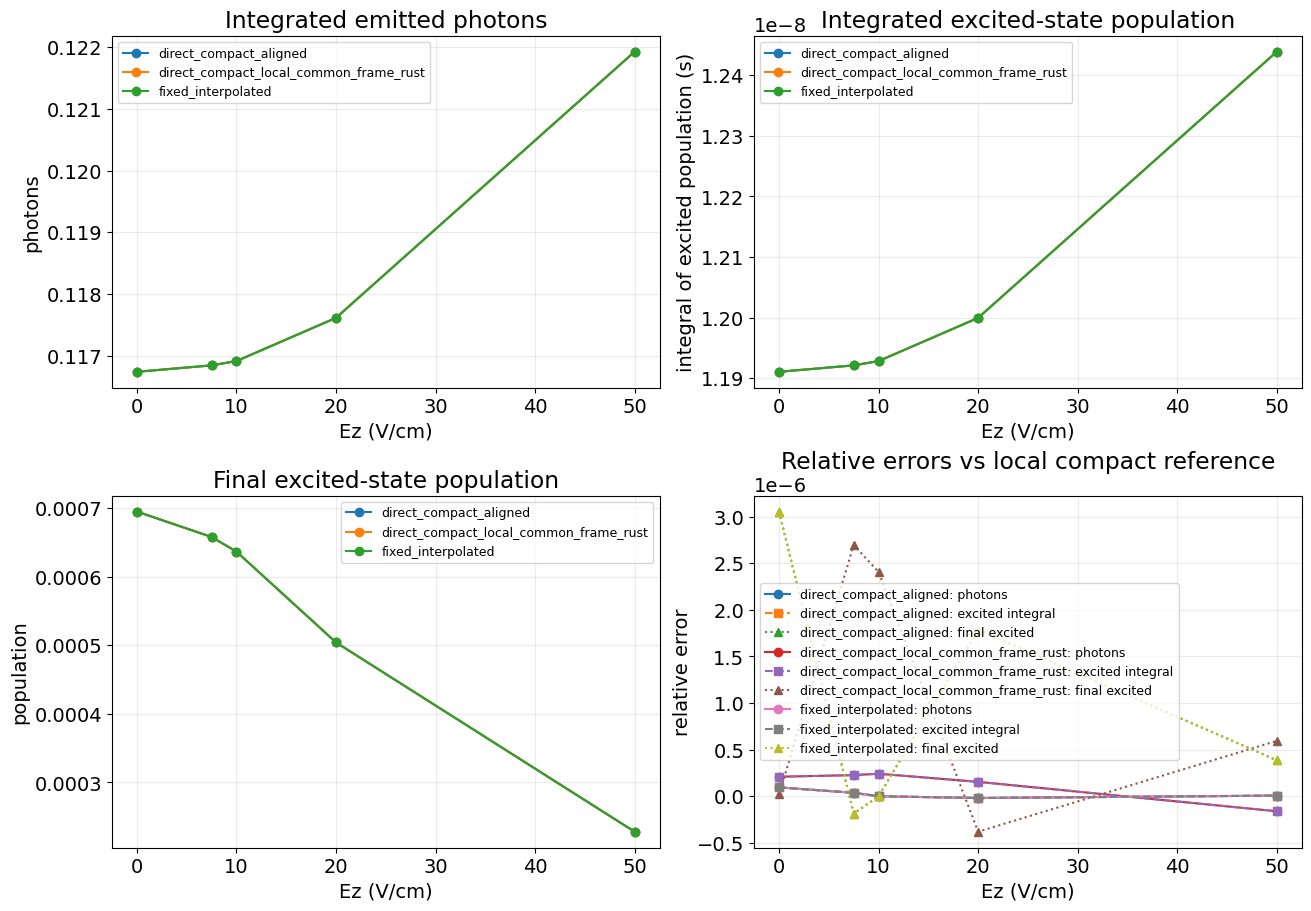

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)

for case, group in observable_df.groupby("case"):
    group = group.sort_values("field_vcm")
    axes[0, 0].plot(group["field_vcm"], group["photons"], marker="o", label=case)
    axes[0, 1].plot(
        group["field_vcm"],
        group["excited_population_integral"],
        marker="o",
        label=case,
    )
    axes[1, 0].plot(
        group["field_vcm"],
        group["final_excited_population"],
        marker="o",
        label=case,
    )

for case, group in comparison_df.groupby("case"):
    group = group.sort_values("field_vcm")
    axes[1, 1].plot(
        group["field_vcm"],
        group["photons_rel_err_vs_local"],
        marker="o",
        label=f"{case}: photons",
    )
    axes[1, 1].plot(
        group["field_vcm"],
        group["excited_integral_rel_err_vs_local"],
        marker="s",
        linestyle="--",
        label=f"{case}: excited integral",
    )
    axes[1, 1].plot(
        group["field_vcm"],
        group["final_excited_rel_err_vs_local"],
        marker="^",
        linestyle=":",
        label=f"{case}: final excited",
    )

axes[0, 0].set_title("Integrated emitted photons")
axes[0, 0].set_xlabel("Ez (V/cm)")
axes[0, 0].set_ylabel("photons")

axes[0, 1].set_title("Integrated excited-state population")
axes[0, 1].set_xlabel("Ez (V/cm)")
axes[0, 1].set_ylabel("integral of excited population (s)")

axes[1, 0].set_title("Final excited-state population")
axes[1, 0].set_xlabel("Ez (V/cm)")
axes[1, 0].set_ylabel("population")

axes[1, 1].set_title("Relative errors vs local compact reference")
axes[1, 1].set_xlabel("Ez (V/cm)")
axes[1, 1].set_ylabel("relative error")

for ax in axes.ravel():
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

plt.show()

## Focused Excited-Population Trace

Use this plot for the field where the final excited-state population looks most different. The lower panel subtracts the local compact bundle solve, so a large `local_compact_rust` residual points at solver/path differences rather than interpolation.

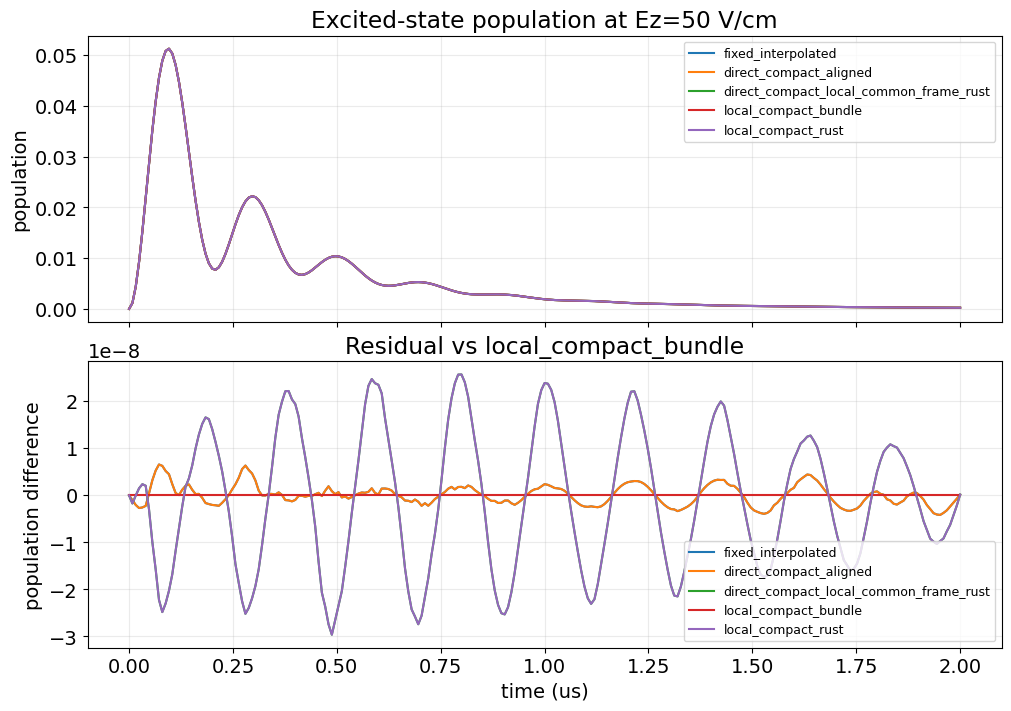

,field_vcm,case,photons_rel_err_vs_local,excited_integral_rel_err_vs_local,final_excited_abs_err_vs_local,final_excited_rel_err_vs_local,max_excited_abs_err_vs_local,max_excited_rel_err_vs_local
13,50.0,direct_compact_aligned,6.880948e-09,6.880948e-09,8.813104e-11,3.860827e-07,6.547667e-09,1.277381e-07
14,50.0,direct_compact_local_common_frame_rust,-1.609740e-07,-1.609740e-07,1.356022e-10,5.940435e-07,2.963060e-08,5.780616e-07
12,50.0,fixed_interpolated,6.880957e-09,6.880949e-09,8.813106e-11,3.860828e-07,6.547667e-09,1.277381e-07


In [12]:
FOCUS_FIELD_VCM = 50.0

focus_field = float(FOCUS_FIELD_VCM)
available_fields = sorted({field for field, _ in last_traces})
if focus_field not in available_fields:
    focus_field = min(available_fields, key=lambda field: abs(field - FOCUS_FIELD_VCM))

local_case = next(
    case
    for field, case in last_traces
    if field == focus_field and case.startswith("direct_compact_local")
)
focus_cases = [
    ("fixed_interpolated", last_traces[(focus_field, "fixed_interpolated")]),
    ("direct_compact_aligned", last_traces[(focus_field, "direct_compact_aligned")]),
    (local_case, last_traces[(focus_field, local_case)]),
]

reference_label = local_case
reference_trace = last_traces[(focus_field, local_case)]
if (focus_field, "local_compact_bundle") in local_solver_traces:
    reference_label = "local_compact_bundle"
    reference_trace = local_solver_traces[(focus_field, reference_label)]
    focus_cases.append((reference_label, reference_trace))
if (focus_field, "local_compact_rust") in local_solver_traces:
    focus_cases.append(
        ("local_compact_rust", local_solver_traces[(focus_field, "local_compact_rust")])
    )

fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
ref_t = np.asarray(reference_trace["t"], dtype=float)
ref_excited = np.asarray(reference_trace["excited_population"], dtype=float)

for label, record in focus_cases:
    t = np.asarray(record["t"], dtype=float)
    excited = np.asarray(record["excited_population"], dtype=float)
    axes[0].plot(1e6 * t, excited, label=label)

    if t.shape == ref_t.shape and np.allclose(t, ref_t):
        residual_t = t
        residual = excited - ref_excited
    else:
        residual_t = ref_t
        residual = np.interp(ref_t, t, excited) - ref_excited
    axes[1].plot(1e6 * residual_t, residual, label=label)

axes[0].set_title(f"Excited-state population at Ez={focus_field:g} V/cm")
axes[0].set_ylabel("population")
axes[1].set_title(f"Residual vs {reference_label}")
axes[1].set_xlabel("time (us)")
axes[1].set_ylabel("population difference")

for ax in axes:
    ax.grid(alpha=0.25)
    ax.legend(fontsize=9)

plt.show()

focus_summary = comparison_df[comparison_df["field_vcm"] == focus_field].copy()
focus_summary.sort_values("case")

## Interpretation Checklist

- At patch fields, `fixed_interpolated` should be close to `direct_compact_aligned` up to alignment/numerical differences.
- `dissipator_rel_vs_aligned_c_array` is the Lindblad-safe kernel reconstruction diagnostic.
- At non-patch fields, the difference measures interpolation quality.
- `direct_compact_aligned` and `direct_compact_local_common_frame_*` should agree in photons, integrated excited population, and the focused excited-population trace. If not, inspect the initial-state choice, detuning-frame correction, and compact embedding/alignment.
- `local_compact_bundle` and `local_compact_rust` should agree under the same tolerances. If not, the discrepancy is in the solver/output path rather than in the interpolated Hamiltonian model.
- If the static comparison is poor, do not trust the time-dependent fixed-basis interpolation yet.
- If the static comparison is good, the next validation step is the full time-dependent fixed-basis model against a larger un-compacted fixed-basis OBE convergence reference.